# SEED-OLF 数据审计

## tl;dr

- 数据集包含 **4,608 个 PKL 实验文件**，实际 PKL 体积 **6.858 GB（6.386 GiB）**。
- `clean_breathing` 和 `stimulation` 各有 2,304 个文件，完整覆盖 **32 名被试 × 3 个 Session × 24 个 Trial**；两个阶段按 `(subject, session, trial)` 100% 配对。
- 每个 PKL 都含 `X_raw / y_emotion / y_odor / y_sniff`；EEG 固定为 **62 × 3,000、float64**，无 NaN、Inf、全零或平坦通道。
- 刺激阶段的4类气味完全平衡，各576次；主观二元情绪标签为 `0: 1,306`、`1: 998`，并存在明显被试差异。
- 由多数标签推断，气味1/2偏向情绪0，气味3/4偏向情绪1；总体主客观一致率约 **80.38%**，气味4只有 **55.38%**，说明个体差异非常重要。
- EEG 中存在需清理的高幅值试次：刺激阶段184个文件峰值超过500 µV，71个超过1,000 µV，最高9,233 µV。建模前必须做滤波、重参考、坏道/伪迹处理和按被试划分。
- 数据文件本身没有采样率、通道名称、气味真实名称/成分、浓度、时间戳、arousal、PPG或EDA，因此不能单独支撑完整的 MindScents 闭环系统。


## Context & Methods

### Key Assumptions

- 文件名解释为 `被试_Session_Trial.pkl`，由完整编号结构和官方实验设计共同支持。
- `y_emotion` 被视为主观二元效价标签，`y_odor` 为4种气味ID；具体文字类别和气味名称未包含在下载包中。
- 3,000点对应15秒刺激时，采样率推断为200 Hz；采样率并未作为字段存储，因此这是推断而非文件内确认。
- 本审计只读数据，不修改任何 PKL。

检查包括：目录完整性、主键唯一性、阶段配对、Pickle引用安全检查、schema/shape/dtype一致性、标签分布、fold完整性、NaN/Inf、平坦通道、幅值和高幅伪迹率。

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import os
import pickle
import pickletools
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path(os.environ['SEED_OLF_DATA_ROOT']).expanduser().resolve()
PHASES = ['clean_breathing', 'stimulation']
FILE_PATTERN = re.compile(r'^(\d{2})_(\d)_(\d{1,2})\.pkl$')

assert DATA_ROOT.is_dir(), f'数据目录不存在：{DATA_ROOT}'
print('Data root:', DATA_ROOT)


Data root: $SEED_OLF_DATA_ROOT


## Data

### 1. 目录、容量和编号完整性

In [2]:
manifest_rows = []
for phase in PHASES:
    for path in sorted((DATA_ROOT / phase).glob('*.pkl')):
        match = FILE_PATTERN.match(path.name)
        ids = tuple(map(int, match.groups())) if match else (None, None, None)
        manifest_rows.append({
            'phase': phase,
            'subject': ids[0],
            'session': ids[1],
            'trial': ids[2],
            'filename': path.name,
            'path': path,
            'bytes': path.stat().st_size,
        })

manifest = pd.DataFrame(manifest_rows)
expected_keys = {(subject, session, trial)
                 for subject in range(1, 33)
                 for session in range(1, 4)
                 for trial in range(1, 25)}

summary = []
for phase in PHASES:
    part = manifest[manifest.phase == phase]
    keys = set(zip(part.subject, part.session, part.trial))
    summary.append({
        'phase': phase,
        'files': len(part),
        'GB': part.bytes.sum() / 1e9,
        'GiB': part.bytes.sum() / 1024**3,
        'missing_keys': len(expected_keys - keys),
        'unexpected_keys': len(keys - expected_keys),
        'duplicate_keys': len(part) - len(keys),
    })

display(pd.DataFrame(summary).round(4))
print('Total PKL bytes:', f"{manifest.bytes.sum():,}")
print('Total:', f"{manifest.bytes.sum()/1e9:.3f} GB / {manifest.bytes.sum()/1024**3:.3f} GiB")


,phase,files,GB,GiB,missing_keys,unexpected_keys,duplicate_keys
0,clean_breathing,2304,3.4289,3.1934,0,0,0
1,stimulation,2304,3.4291,3.1936,0,0,0


Total PKL bytes: 6,857,991,936
Total: 6.858 GB / 6.387 GiB


### 2. Pickle 引用安全检查

先反汇编代表性 Pickle，只查看其引用的全局构造函数，不执行对象加载。

In [3]:
for phase in PHASES:
    path = DATA_ROOT / phase / '01_1_1.pkl'
    global_refs = []
    protocol = None
    for opcode, argument, position in pickletools.genops(path.read_bytes()):
        if opcode.name == 'PROTO':
            protocol = argument
        if opcode.name in {'GLOBAL', 'STACK_GLOBAL'}:
            global_refs.append((opcode.name, argument, position))
    print(phase, 'protocol=', protocol, 'global references=', global_refs)


clean_breathing protocol= 3 global references= [('GLOBAL', 'numpy.core.multiarray _reconstruct', 18), ('GLOBAL', 'numpy ndarray', 56), ('GLOBAL', 'numpy dtype', 100)]
stimulation protocol= 3 global references= [('GLOBAL', 'numpy.core.multiarray _reconstruct', 18), ('GLOBAL', 'numpy ndarray', 56), ('GLOBAL', 'numpy dtype', 100), ('GLOBAL', 'numpy.core.multiarray scalar', 1488190)]


### 3. 流式读取全部文件并建立质量画像

In [4]:
profile_rows = []

for phase in PHASES:
    phase_manifest = manifest[manifest.phase == phase]
    for index, row in enumerate(phase_manifest.itertuples(index=False), start=1):
        with row.path.open('rb') as handle:
            payload = pickle.load(handle)

        eeg = payload['X_raw']
        channel_std_uv = np.std(eeg, axis=1) * 1e6
        profile_rows.append({
            'phase': phase,
            'subject': row.subject,
            'session': row.session,
            'trial': row.trial,
            'filename': row.filename,
            'keys': tuple(payload.keys()),
            'shape': tuple(eeg.shape),
            'dtype': str(eeg.dtype),
            'nonfinite': int(eeg.size - np.isfinite(eeg).sum()),
            'zero_count': int(np.count_nonzero(eeg == 0)),
            'flat_channels': int(np.count_nonzero(channel_std_uv == 0)),
            'peak_uv': float(np.max(np.abs(eeg)) * 1e6),
            'global_std_uv': float(np.std(eeg) * 1e6),
            'median_channel_std_uv': float(np.median(channel_std_uv)),
            'over_500uv_rate': float(np.mean(np.abs(eeg) > 500e-6)),
            'y_emotion': payload['y_emotion'],
            'y_odor': payload['y_odor'],
            'y_sniff': payload['y_sniff'],
        })
    print(f'Loaded {phase}: {len(phase_manifest)} files')

profile = pd.DataFrame(profile_rows)
profile.head()


Loaded clean_breathing: 2304 files
Loaded stimulation: 2304 files


,phase,subject,session,trial,filename,keys,shape,dtype,nonfinite,zero_count,flat_channels,peak_uv,global_std_uv,median_channel_std_uv,over_500uv_rate,y_emotion,y_odor,y_sniff
0,clean_breathing,1,1,1,01_1_1.pkl,"(X_raw, y_emotion, y_odor, y_sniff)","(62, 3000)",float64,0,0,0,248.769859,16.613695,10.643548,0.0,NaN,NaN,0
1,clean_breathing,1,1,10,01_1_10.pkl,"(X_raw, y_emotion, y_odor, y_sniff)","(62, 3000)",float64,0,0,0,239.109852,16.886007,12.520033,0.0,NaN,NaN,0
2,clean_breathing,1,1,11,01_1_11.pkl,"(X_raw, y_emotion, y_odor, y_sniff)","(62, 3000)",float64,0,0,0,279.704341,21.117738,12.560511,0.0,NaN,NaN,0
3,clean_breathing,1,1,12,01_1_12.pkl,"(X_raw, y_emotion, y_odor, y_sniff)","(62, 3000)",float64,0,0,0,110.848035,11.821062,8.033841,0.0,NaN,NaN,0
4,clean_breathing,1,1,13,01_1_13.pkl,"(X_raw, y_emotion, y_odor, y_sniff)","(62, 3000)",float64,0,0,0,228.738299,18.833022,12.319203,0.0,NaN,NaN,0


## Results

### 4. Schema、维度和完整性

In [5]:
structural_rows = []
for phase in PHASES:
    part = profile[profile.phase == phase]
    structural_rows.append({
        'phase': phase,
        'files': len(part),
        'unique_schema': part['keys'].nunique(),
        'unique_shape': part['shape'].nunique(),
        'shape': part['shape'].iloc[0],
        'dtype': ', '.join(sorted(part['dtype'].unique())),
        'files_with_nonfinite': int((part.nonfinite > 0).sum()),
        'files_with_flat_channels': int((part.flat_channels > 0).sum()),
        'files_with_zeros': int((part.zero_count > 0).sum()),
    })
display(pd.DataFrame(structural_rows))

clean_keys = set(map(tuple, profile[profile.phase == 'clean_breathing'][['subject','session','trial']].to_numpy()))
stim_keys = set(map(tuple, profile[profile.phase == 'stimulation'][['subject','session','trial']].to_numpy()))
print('Paired keys:', len(clean_keys & stim_keys))
print('Only clean:', len(clean_keys - stim_keys), '| Only stimulation:', len(stim_keys - clean_keys))


,phase,files,unique_schema,unique_shape,shape,dtype,files_with_nonfinite,files_with_flat_channels,files_with_zeros
0,clean_breathing,2304,1,1,"(62, 3000)",float64,0,0,0
1,stimulation,2304,1,1,"(62, 3000)",float64,0,0,0


Paired keys: 2304
Only clean: 0 | Only stimulation: 0


### 5. 标签分布和实验平衡

In [6]:
stim = profile[profile.phase == 'stimulation'].copy()
stim['y_emotion'] = stim['y_emotion'].astype(int)
stim['y_odor'] = stim['y_odor'].astype(int)

print('y_sniff by phase')
display(pd.crosstab(profile.phase, profile.y_sniff))
print('Odor × subjective emotion')
odor_emotion = pd.crosstab(stim.y_odor, stim.y_emotion, margins=True)
display(odor_emotion)

subject_emotion = pd.crosstab(stim.subject, stim.y_emotion)
subject_emotion['positive_rate'] = subject_emotion.get(1, 0) / subject_emotion.sum(axis=1)
display(subject_emotion.sort_values('positive_rate').head(8))
display(subject_emotion.sort_values('positive_rate').tail(8))


y_sniff by phase


y_sniff,0,1
phase,,
clean_breathing,2304,0
stimulation,0,2304


Odor × subjective emotion


y_emotion,0,1,All
y_odor,,,
1,489,87,576
2,514,62,576
3,46,530,576
4,257,319,576
All,1306,998,2304


y_emotion,0,1,positive_rate
subject,,,
7,59,13,0.180556
32,56,16,0.222222
22,53,19,0.263889
3,51,21,0.291667
12,48,24,0.333333
21,48,24,0.333333
30,48,24,0.333333
20,44,28,0.388889


y_emotion,0,1,positive_rate
subject,,,
10,36,36,0.500000
26,36,36,0.500000
6,35,37,0.513889
19,35,37,0.513889
13,34,38,0.527778
2,32,40,0.555556
4,30,42,0.583333
16,30,42,0.583333


In [7]:
# 验证每个4-trial fold是否恰好包含一次气味1、2、3、4
stim['fold'] = (stim.trial - 1) // 4 + 1
fold_counts = stim.groupby(['subject','session','fold']).y_odor.agg(lambda values: tuple(sorted(values)))
bad_folds = fold_counts[fold_counts != (1, 2, 3, 4)]
print('Total folds:', len(fold_counts), '| malformed folds:', len(bad_folds))

# 由每种气味的多数主观标签推断客观二元效价映射
majority_mapping = stim.groupby('y_odor').y_emotion.agg(lambda values: int(values.mode().iloc[0])).to_dict()
stim['majority_odor_valence'] = stim.y_odor.map(majority_mapping)
stim['subjective_objective_agree'] = stim.y_emotion == stim.majority_odor_valence
print('Inferred mapping:', majority_mapping)
print('Overall agreement:', f"{stim.subjective_objective_agree.mean():.4%}")
display(stim.groupby('y_odor').subjective_objective_agree.agg(['sum','count','mean']).round(4))


Total folds: 576 | malformed folds: 0
Inferred mapping: {1: 0, 2: 0, 3: 1, 4: 1}
Overall agreement: 80.3819%


,sum,count,mean
y_odor,,,
1,489,576,0.8490
2,514,576,0.8924
3,530,576,0.9201
4,319,576,0.5538


### 6. EEG 数值质量与高幅值伪迹候选

In [8]:
artifact_rows = []
for phase in PHASES:
    part = profile[profile.phase == phase]
    artifact_rows.append({
        'phase': phase,
        'peak > 500 µV': int((part.peak_uv > 500).sum()),
        'peak > 1000 µV': int((part.peak_uv > 1000).sum()),
        'peak > 2000 µV': int((part.peak_uv > 2000).sum()),
        'median ch std > 50 µV': int((part.median_channel_std_uv > 50).sum()),
        '>1% samples over 500 µV': int((part.over_500uv_rate > 0.01).sum()),
        'max peak µV': part.peak_uv.max(),
    })
display(pd.DataFrame(artifact_rows).round(2))

top_anomalies = profile.nlargest(15, 'peak_uv')[
    ['phase','filename','subject','session','trial','peak_uv','median_channel_std_uv','over_500uv_rate']
]
display(top_anomalies.round(4))


,phase,peak > 500 µV,peak > 1000 µV,peak > 2000 µV,median ch std > 50 µV,>1% samples over 500 µV,max peak µV
0,clean_breathing,142,43,18,27,14,4521.90
1,stimulation,184,71,24,39,19,9233.12


,phase,filename,subject,session,trial,peak_uv,median_channel_std_uv,over_500uv_rate
3244,stimulation,14_1_13.pkl,14,1,13,9233.1150,20.2028,0.0013
4230,stimulation,27_3_15.pkl,27,3,15,5801.1671,85.9837,0.0316
3980,stimulation,24_1_6.pkl,24,1,6,4965.8266,39.3284,0.0140
3742,stimulation,20_3_8.pkl,20,3,8,4874.5878,20.8552,0.0004
3784,stimulation,21_2_24.pkl,21,2,24,4721.9012,58.9710,0.0137
3975,stimulation,24_1_23.pkl,24,1,23,4650.9017,53.2917,0.0214
3963,stimulation,24_1_12.pkl,24,1,12,4562.3569,40.1067,0.0083
900,clean_breathing,13_2_20.pkl,13,2,20,4521.9045,23.6039,0.0040
3913,stimulation,23_2_10.pkl,23,2,10,4241.7631,17.9958,0.0004
3969,stimulation,24_1_18.pkl,24,1,18,4175.7887,34.5082,0.0176


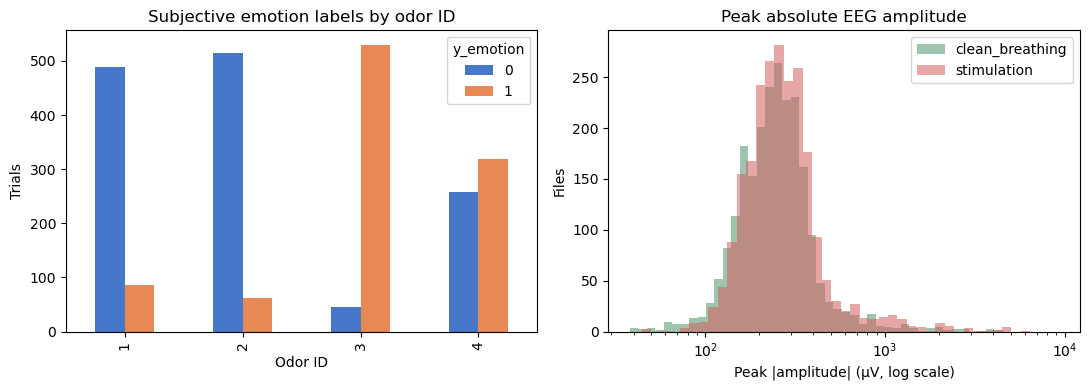

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

odor_emotion_no_total = pd.crosstab(stim.y_odor, stim.y_emotion)
odor_emotion_no_total.plot(kind='bar', ax=axes[0], color=['#4677C8', '#E88955'])
axes[0].set_title('Subjective emotion labels by odor ID')
axes[0].set_xlabel('Odor ID')
axes[0].set_ylabel('Trials')
axes[0].legend(title='y_emotion')

for phase, color in [('clean_breathing', '#4C956C'), ('stimulation', '#D65F5F')]:
    values = profile.loc[profile.phase == phase, 'peak_uv']
    axes[1].hist(values, bins=np.logspace(np.log10(values.min()), np.log10(values.max()), 45),
                 alpha=0.55, label=phase, color=color)
axes[1].set_xscale('log')
axes[1].set_title('Peak absolute EEG amplitude')
axes[1].set_xlabel('Peak |amplitude| (µV, log scale)')
axes[1].set_ylabel('Files')
axes[1].legend()

plt.tight_layout()
plt.show()


## Takeaways

1. **完整性高。** 实验主键、两阶段配对、schema、shape和气味类别平衡全部通过检查，适合作为嗅觉EEG分类基准。
2. **标签包含有价值的个体差异。** 气味4的主客观一致率仅约55%，不是可直接当作统一正向刺激的稳定类别；MindScents应保留自评，不应只使用气味预设效价。
3. **需要EEG清洗。** 数据虽无NaN、Inf或平坦通道，但存在高幅值试次。不能把 `X_raw` 直接输入模型；建议至少完成带通/陷波、重参考、坏段/坏道检测、眼动肌电伪迹处理和稳健缩放。
4. **切分必须按被试。** 每位被试有72个高度相关的重复试次；随机按trial切分会造成同一被试泄漏到训练与测试，显著高估跨用户效果。
5. **数据包缺少语义元数据。** 文件内没有采样率、通道名称、气味名称/成分/浓度、设备信息、时间戳或人口统计，需要论文/作者说明才能完整解释。
6. **只覆盖MindScents的一部分。** 可支持嗅探识别、主观效价、气味ID分类和个体差异研究；不能直接支持arousal、PPG/EDA、气味剂量反应、配方优化、偏好排序或闭环推荐。

建议把稳定的自动测试固定为：文件主键完整且唯一、两个阶段100%配对、schema/shape/dtype一致、标签允许值、每个fold含4个不同气味、无NaN/Inf、无平坦通道，以及高幅值伪迹报告。